In [19]:
import os
import sys
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Personal imports
sys.path.append("{}/../../../analysis_code/utils".format(os.getcwd()))
from plot_utils import plotly_template

In [23]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")
settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]

subjects = analysis_info['subjects']

In [2]:
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'RetinoMaps'
subject = 'group'

# Plot

In [8]:
pRF_beh_tsv_dir = '{}/{}/derivatives/pp_data/{}/pRF_beh/tsv'.format(main_dir, project_dir, subject)

pRF_beh_trials_fn = '{}/{}_pRF_beh_trials.tsv'.format(pRF_beh_tsv_dir, subject)

In [10]:
pRF_beh_trials = pd.read_table(pRF_beh_trials_fn)

In [17]:
template_specs = dict(axes_color="rgba(0, 0, 0, 1)",
                      axes_width=2,
                      axes_font_size=15,
                      bg_col="rgba(255, 255, 255, 1)",
                      font='Arial',
                      title_font_size=15,
                      rois_plot_width=1.5)

# General figure settings
fig_template = plotly_template(template_specs)

In [21]:
# color_map
colormap_subject_dict = {
    'sub-01': '#AA0DFE',
    'sub-02': '#3283FE',
    'sub-03': '#85660D',
    'sub-04': '#782AB6',
    'sub-05': '#565656',
    'sub-06': '#1C8356',
    'sub-07': '#16FF32',
    'sub-08': '#F7E1A0',
    'sub-09': '#E2E2E2',
    'sub-11': '#1CBE4F',
    'sub-12': '#C4451C',
    'sub-13': '#DEA0FD',
    'sub-14': '#FBE426',
    'sub-15': '#325A9B',
    'sub-16': '#FEAF16',
    'sub-17': '#F8A19F',
    'sub-18': '#90AD1C',
    'sub-20': '#F6222E',
    'sub-21': '#1CFFCE',
    'sub-22': '#2ED9FF',
    'sub-23': '#B10DA1',
    'sub-24': '#C075A6',
    'sub-25': '#FC1CBF'
}

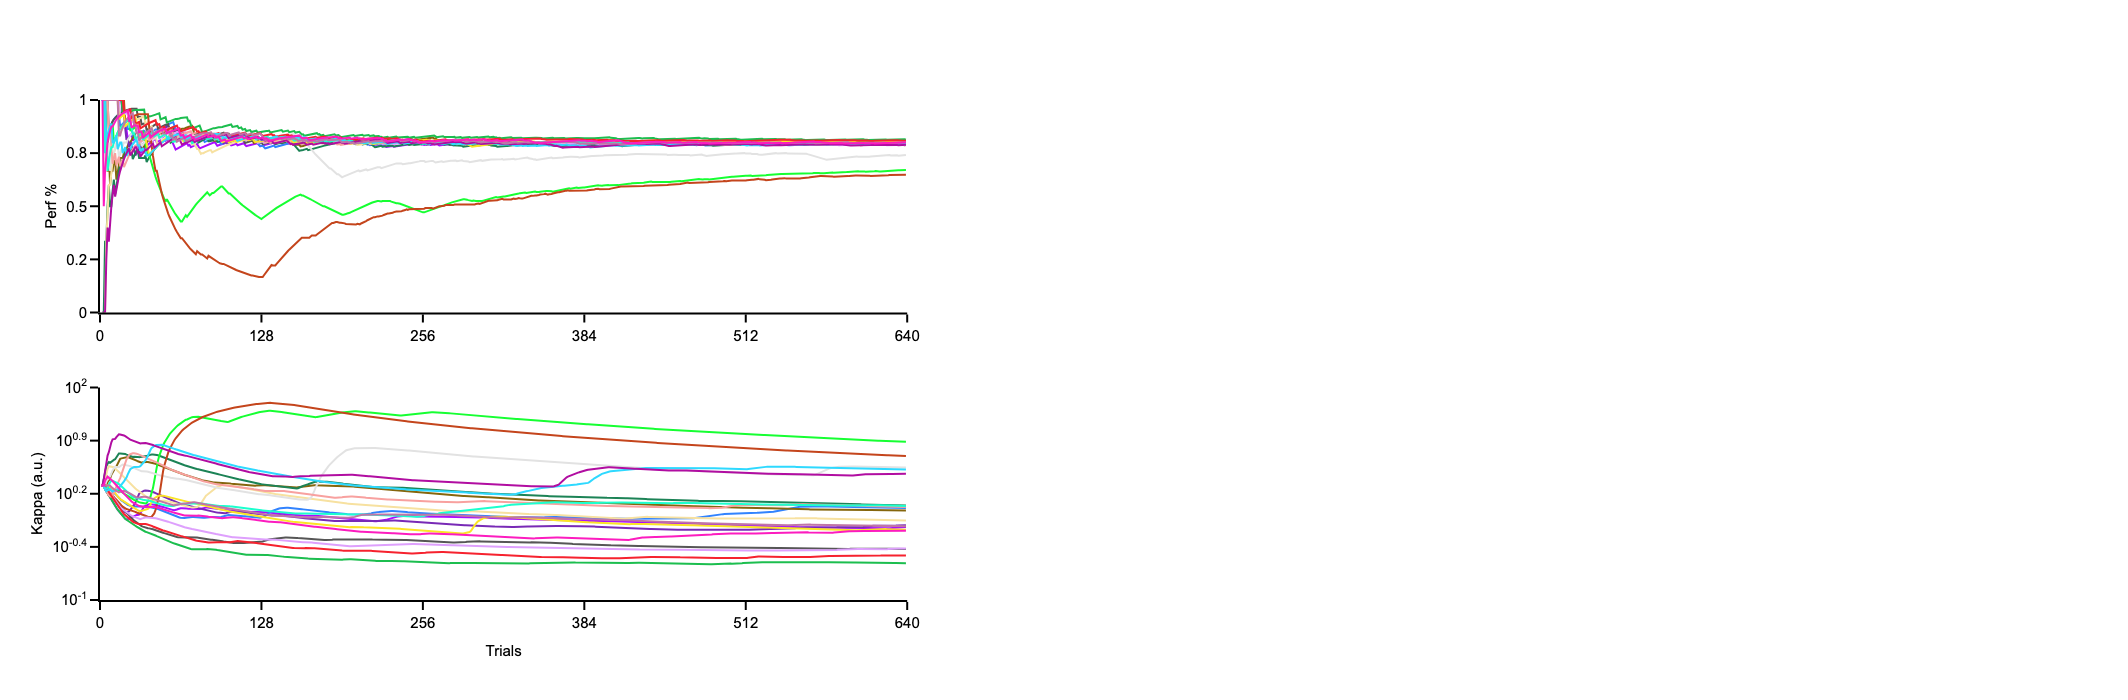

In [50]:
step = 128
x_max = 640

perf_range = [0, 1]
kappa_range = [-1, 1.5]
num_step_y_axes = 5

fig = make_subplots(
    rows=2, cols=3,
    column_widths=[0.5, 0.5, 0],
    horizontal_spacing=0.1,
    specs=[[{}, {"rowspan": 2}, {'type': 'polar'}],
           [{}, None, None]]
)

for n_subject, subject_to_plot in enumerate(subjects):
    pRF_beh_trials_subject = pRF_beh_trials.loc[pRF_beh_trials['subject']==subject_to_plot]

    # Perf 
    # plot perf across trials 
    fig.add_trace(go.Scatter(y=pRF_beh_trials_subject['perf'], 
                             line=dict(color=colormap_subject_dict[subject_to_plot]), 
                             name=subject_to_plot, 
                             showlegend=False), 
                  row=1, col=1)

    # Staircase 
    fig.add_trace(go.Scatter(y=np.log10(pRF_beh_trials_subject['stair']), 
                             line=dict(color=colormap_subject_dict[subject_to_plot]), 
                             name=subject_to_plot), 
                  row=2, col=1)

fig.update_xaxes(showline=True, 
                 range=[0,x_max], 
                 tickvals=[0, 128, 256, 384, 512, 640], 
                 ticktext=["0", "128", "256", "384", "512", "640"], 
                 row=1, col=1)

tickvals = np.linspace(perf_range[0], perf_range[1], num_step_y_axes)
ticktext = [f"{v:.1g}" for v in tickvals]

fig.update_yaxes(
    showline=True,
    range=[perf_range[0], perf_range[1]],
    tickvals=tickvals,
    ticktext=ticktext,
    title='Perf %',
    row=1, col=1
)

# stair 
fig.update_xaxes(showline=True, range=[0,x_max], 
                 tickvals=[0, 128, 256, 384, 512, 640], 
                 ticktext=["0", "128", "256", "384", "512", "640"], 
                 title='Trials', 
                 row=2, col=1)

tickvals = np.linspace(kappa_range[0], kappa_range[1], num_step_y_axes)
ticktext = [f"10<sup>{v:.1g}</sup>" for v in tickvals]
fig.update_yaxes(
    showline=True,
    range=[kappa_range[0], kappa_range[1]],
    tickvals=tickvals,
    ticktext=ticktext,
    title='Kappa (a.u.)',
    row=2, col=1
)

# Update layout
fig.update_layout(template=fig_template, 
                  width=1420, 
                  height=700, 
                  margin=dict(l=100, r=10, b=100, t=100),
                  showlegend=False, 
                  # legend=dict(orientation="v", 
                  #             yanchor="top", 
                  #             y=1, 
                  #             xanchor="left", 
                  #             x=1.05)
                 )
fig_dir = '/Users/uriel/Library/CloudStorage/Dropbox/retinomaps/figures/material/pRF_figures/pRF_beh'
os.makedirs(fig_dir, exist_ok=True)
fig.write_image("{}/{}_pRF_beh_trials.pdf".format(fig_dir, subject))
fig.show()

In [41]:
ticktext

['10<sup>-1</sup>',
 '10<sup>-0.4</sup>',
 '10<sup>0.2</sup>',
 '10<sup>0.9</sup>',
 '10<sup>2</sup>']

In [28]:
pRF_beh_trials_subject['stair']


12160         NaN
12161    2.218982
12162    2.218982
12163    2.218982
12164    2.528014
           ...   
12795    0.655429
12796    0.654992
12797    0.654556
12798    0.653910
12799    0.653266
Name: stair, Length: 640, dtype: float64

# Values

In [3]:
pRF_beh_tsv_dir = '{}/{}/derivatives/pp_data/{}/pRF_beh/tsv'.format(main_dir, project_dir, subject)
pRF_beh_trials_group_median_fn = '{}/{}_pRF_beh_trials_group_median.tsv'.format(pRF_beh_tsv_dir, subject)
pRF_beh_median_group_median_fn = '{}/{}_pRF_beh_median_group_median.tsv'.format(pRF_beh_tsv_dir, subject)

In [4]:
pRF_beh_median_group_median = pd.read_table(pRF_beh_median_group_median_fn)

In [6]:
# group
g = pRF_beh_median_group_median[pRF_beh_median_group_median.subject == "group"].iloc[0]

print(

f"Group performance: {g.perf_median*100:.2f}% "

f"[{g.perf_ci_low*100:.2f}, {g.perf_ci_up*100:.2f}]; "

f"κ: 10^({np.log10(g.stair_median):.2f}) "

f"[10^{np.log10(g.stair_ci_low):.2f}, 10^{np.log10(g.stair_ci_up):.2f}]"

)

# outliers

for s in ["sub-07", "sub-12"]:

    r = pRF_beh_median_group_median[pRF_beh_median_group_median.subject == s].iloc[0]

    print(

    f"{s}: performance ~ 57–58%; "

    f"κ: 10^({np.log10(r.stair_median):.2f}) "

    f"[10^{np.log10(r.stair_ci_low):.2f}, 10^{np.log10(r.stair_ci_up):.2f}]"

    )

Group performance: 79.97% [78.58, 88.91]; κ: 10^(-0.01) [10^-0.09, 10^0.28]
sub-07: performance ~ 57–58%; κ: 10^(1.07) [10^0.21, 10^1.22]
sub-12: performance ~ 57–58%; κ: 10^(0.91) [10^0.04, 10^1.31]
